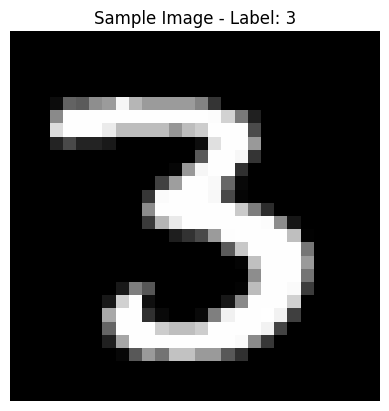

Conv2DLayer output shape: (28, 28, 8)
ReLU output shape: (28, 28, 8)
MaxPoolLayer output shape: (14, 14, 8)
ENOSLayer output shape: (14, 14, 32)


/var/folders/r4/41z2sm312hgff4gflx363rkm0000gn/T/ipykernel_11219/2486263058.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.output[b, i, j, f] = conv


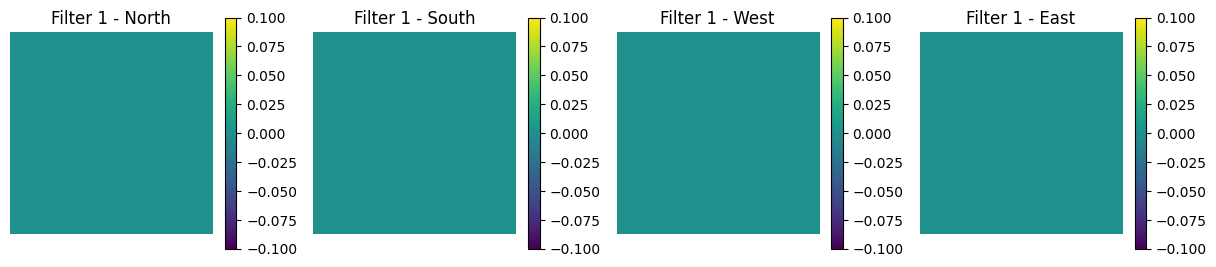

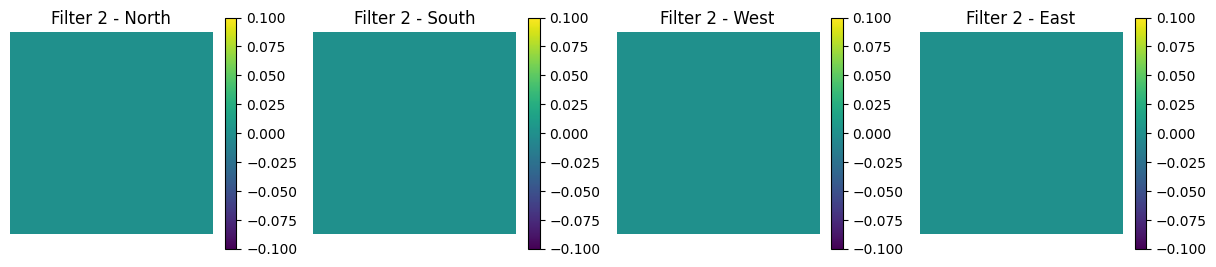

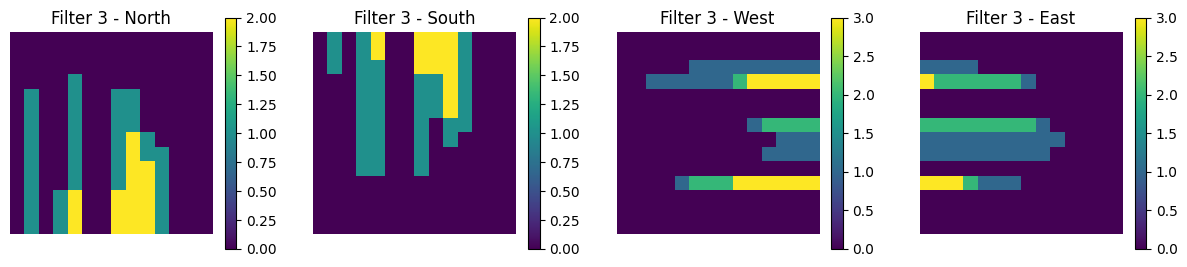

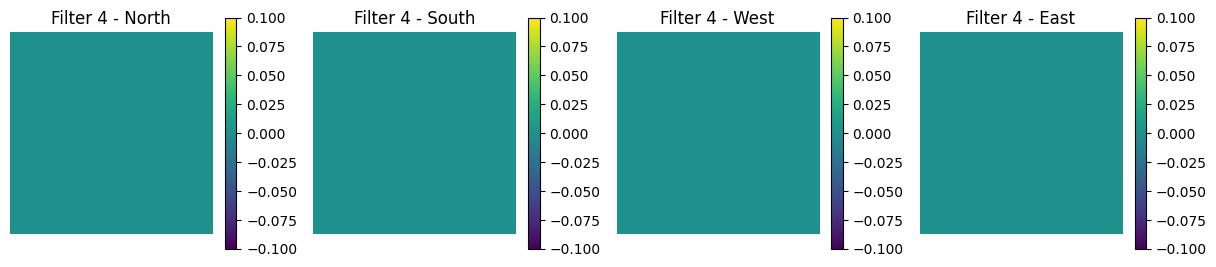

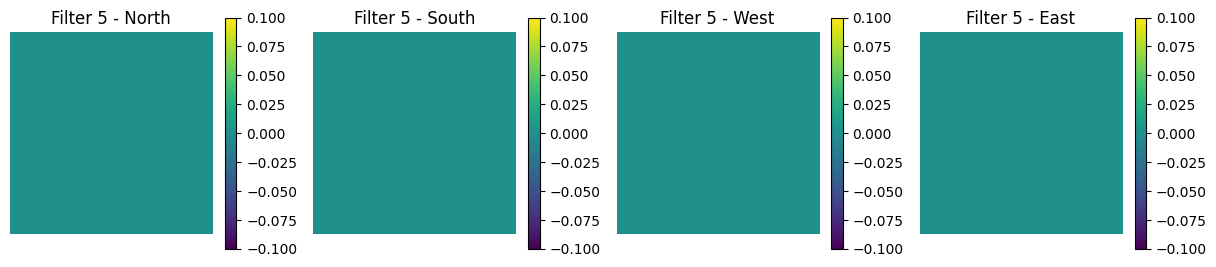

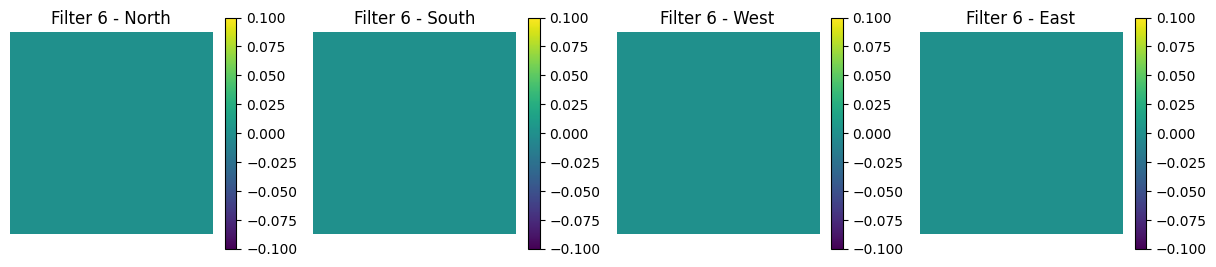

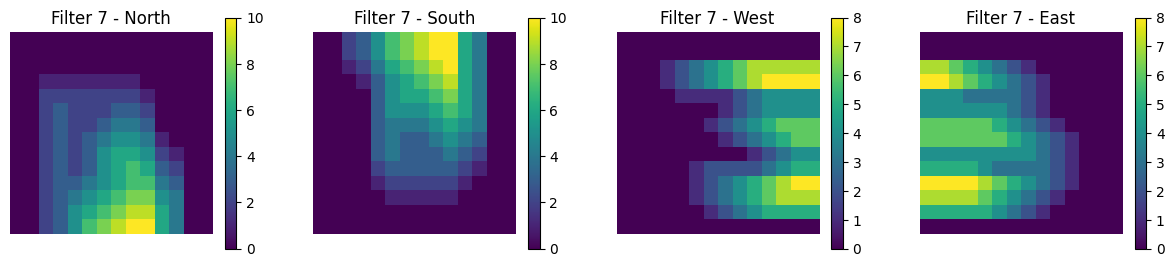

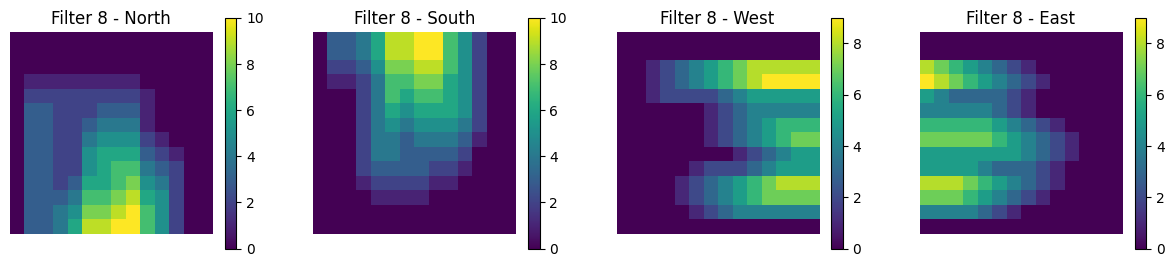

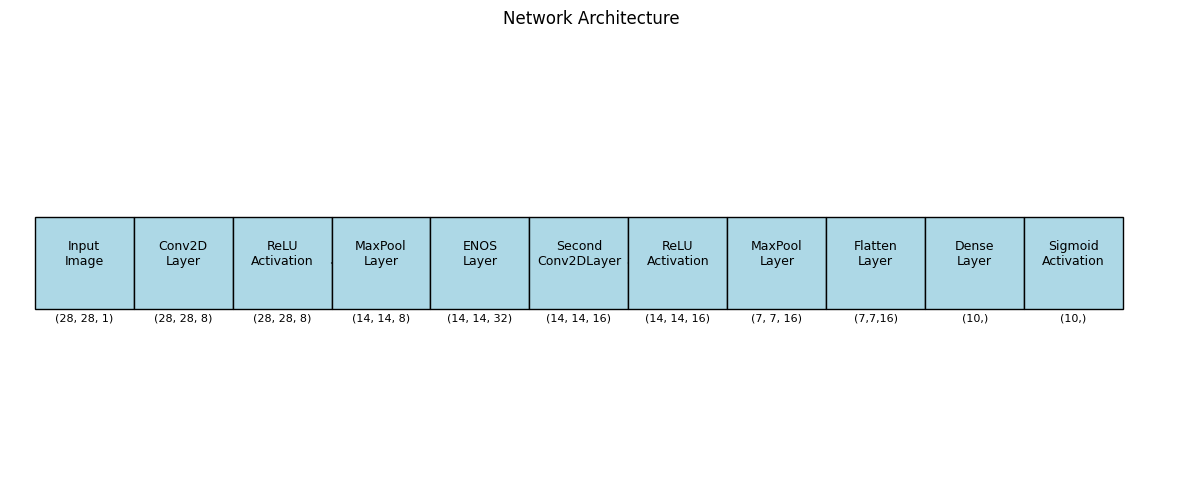

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import matplotlib.patches as patches

# Helper function for Glorot uniform initialization
def glorot_uniform(shape):
    limit = np.sqrt(6 / np.sum(shape))
    return np.random.uniform(-limit, limit, shape)

# Conv2DLayer class
class Conv2DLayer:
    def __init__(self, num_filters, kernel_size, input_shape, stride=1, padding=0):
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.input_shape = input_shape  # (height, width, channels)
        # Initialize weights and biases
        self.weights = glorot_uniform((num_filters, input_shape[2], kernel_size, kernel_size))
        self.biases = np.zeros((num_filters, 1))

    def forward(self, input):
        if input.shape[-1] != self.input_shape[2]:
            raise ValueError(f"Expected {self.input_shape[2]} channels but got {input.shape[-1]}")

        if input.ndim == 4:  # Batch processing
            batch_size, height, width, channels = input.shape
            padded_input = np.pad(
                input, ((0, 0), (self.padding, self.padding), (self.padding, self.padding), (0, 0)),
                mode='constant'
            )
        else:  # Single image
            input = np.expand_dims(input, axis=0)  # Add batch dimension
            batch_size, height, width, channels = input.shape
            padded_input = np.pad(
                input, ((0, 0), (self.padding, self.padding), (self.padding, self.padding), (0, 0)),
                mode='constant'
            )

        self.padded_input = padded_input  # Store for backward pass
        self.input = input  # Store original input for backward pass

        self.output_height = (height + 2 * self.padding - self.kernel_size) // self.stride + 1
        self.output_width = (width + 2 * self.padding - self.kernel_size) // self.stride + 1
        self.output = np.zeros((batch_size, self.output_height, self.output_width, self.num_filters))

        # Perform convolution
        for b in range(batch_size):
            for i in range(self.output_height):
                for j in range(self.output_width):
                    h_start = i * self.stride
                    h_end = h_start + self.kernel_size
                    w_start = j * self.stride
                    w_end = w_start + self.kernel_size
                    region = padded_input[b, h_start:h_end, w_start:w_end, :]  # Shape: (kernel_size, kernel_size, channels)
                    for f in range(self.num_filters):
                        weights_f = self.weights[f].transpose(1, 2, 0)  # Shape: (kernel_size, kernel_size, channels)
                        conv = np.sum(region * weights_f) + self.biases[f]
                        self.output[b, i, j, f] = conv
        return self.output if input.ndim == 4 else self.output[0]  # Remove batch dimension if single image

# ReLU activation class
class ReLU:
    def forward(self, input):
        self.input = input
        self.output = np.maximum(0, input)
        return self.output

# MaxPoolLayer class
class MaxPoolLayer:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, input):
        self.input = input
        if input.ndim == 4:  # If input has batch dimension
            batch_size, height, width, num_filters = input.shape
        else:
            input = np.expand_dims(input, axis=0)  # Add batch dimension
            batch_size, height, width, num_filters = input.shape

        self.output_height = (height - self.pool_size) // self.stride + 1
        self.output_width = (width - self.pool_size) // self.stride + 1
        self.output = np.zeros((batch_size, self.output_height, self.output_width, num_filters))

        # Perform max pooling
        for b in range(batch_size):
            for f in range(num_filters):
                for i in range(self.output_height):
                    for j in range(self.output_width):
                        h_start = i * self.stride
                        h_end = h_start + self.pool_size
                        w_start = j * self.stride
                        w_end = w_start + self.pool_size
                        region = input[b, h_start:h_end, w_start:w_end, f]
                        self.output[b, i, j, f] = np.max(region)
        return self.output if input.ndim == 4 else self.output[0]

# ENOSLayer class
class ENOSLayer:
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def forward(self, input):
        self.input = input
        if input.ndim == 4:  # If input has batch dimension
            batch_size, height, width, num_filters = input.shape
            self.output = np.zeros((batch_size, height, width, 4 * num_filters))
        else:
            input = np.expand_dims(input, axis=0)  # Add batch dimension
            batch_size, height, width, num_filters = input.shape
            self.output = np.zeros((batch_size, height, width, 4 * num_filters))  # 4 directions per filter

        # Perform ENOS direction count
        for b in range(batch_size):
            for f in range(num_filters):
                for i in range(height):
                    for j in range(width):
                        n_count = np.sum(input[b, :i, j, f] > self.threshold)  # North (up)
                        s_count = np.sum(input[b, i+1:, j, f] > self.threshold)  # South (down)
                        w_count = np.sum(input[b, i, :j, f] > self.threshold)  # West (left)
                        e_count = np.sum(input[b, i, j+1:, f] > self.threshold)  # East (right)

                        self.output[b, i, j, 4 * f] = n_count
                        self.output[b, i, j, 4 * f + 1] = s_count
                        self.output[b, i, j, 4 * f + 2] = w_count
                        self.output[b, i, j, 4 * f + 3] = e_count
        return self.output if input.ndim == 4 else self.output[0]

# Load MNIST data
def load_sample_image():
    (X_train, y_train_labels), _ = mnist.load_data()
    # Normalize the image
    X_train = X_train.astype('float32') / 255.0
    # Reshape to (num_samples, 28, 28, 1)
    X_train = X_train.reshape(-1, 28, 28, 1)
    return X_train[12], y_train_labels[12]  # Return the first image and label

# Get a sample image and its label
sample_image, sample_label = load_sample_image()

# Display the sample image
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"Sample Image - Label: {sample_label}")
plt.axis('off')
plt.show()

# Initialize the layers
conv_layer = Conv2DLayer(num_filters=8, kernel_size=3, input_shape=(28, 28, 1), stride=1, padding=1)
relu_layer = ReLU()
pool_layer = MaxPoolLayer(pool_size=2, stride=2)
enos_layer = ENOSLayer(threshold=0.5)  # You can adjust the threshold as needed

# Forward pass through Conv2DLayer
conv_output = conv_layer.forward(sample_image)
if conv_output.ndim == 4 and conv_output.shape[0] == 1:
    conv_output = conv_output[0]  # Remove batch dimension
print(f"Conv2DLayer output shape: {conv_output.shape}")

# Forward pass through ReLU
relu_output = relu_layer.forward(conv_output)
print(f"ReLU output shape: {relu_output.shape}")

# Forward pass through MaxPoolLayer
pool_output = pool_layer.forward(relu_output)
if pool_output.ndim == 4 and pool_output.shape[0] == 1:
    pool_output = pool_output[0]  # Remove batch dimension
print(f"MaxPoolLayer output shape: {pool_output.shape}")

# Forward pass through ENOSLayer
enos_output = enos_layer.forward(pool_output)
if enos_output.ndim == 4 and enos_output.shape[0] == 1:
    enos_output = enos_output[0]  # Remove batch dimension
print(f"ENOSLayer output shape: {enos_output.shape}")

# Directions for labeling
directions = ['North', 'South', 'West', 'East']

# Number of original feature maps
num_original_filters = pool_output.shape[2]

# Visualize the ENOS outputs
for f in range(num_original_filters):
    fig, axes = plt.subplots(1, 4, figsize=(15, 3))
    for d in range(4):
        enos_feature_map = enos_output[:, :, f * 4 + d]
        ax = axes[d]
        im = ax.imshow(enos_feature_map, cmap='viridis')
        ax.set_title(f"Filter {f+1} - {directions[d]}")
        ax.axis('off')
        fig.colorbar(im, ax=ax)
    plt.show()

# Visualize the network architecture
def visualize_network_architecture():
    fig, ax = plt.subplots(figsize=(15, 6))

    # Define layers with adjusted names and sizes
    layers = [
        {'name': 'Input\nImage', 'size': '(28, 28, 1)'},
        {'name': 'Conv2D\nLayer', 'size': '(28, 28, 8)'},
        {'name': 'ReLU\nActivation', 'size': '(28, 28, 8)'},
        {'name': 'MaxPool\nLayer', 'size': '(14, 14, 8)'},
        {'name': 'ENOS\nLayer', 'size': '(14, 14, 32)'},
        {'name': 'Second\nConv2DLayer', 'size': '(14, 14, 16)'},
        {'name': 'ReLU\nActivation', 'size': '(14, 14, 16)'},
        {'name': 'MaxPool\nLayer', 'size': '(7, 7, 16)'},
        {'name': 'Flatten\nLayer', 'size': '(7,7,16)'},
        {'name': 'Dense\nLayer', 'size': '(10,)'},
        {'name': 'Sigmoid\nActivation', 'size': '(10,)'}
    ]

    x_start = 0.05
    y_start = 0.5
    layer_width = 0.2  # Increased width for longer names

    for idx, layer in enumerate(layers):
        # Draw the rectangle for each layer
        rect = patches.Rectangle(
            (x_start + idx * layer_width, y_start - 0.1),
            layer_width,
            0.2,
            linewidth=1,
            edgecolor='black',
            facecolor='lightblue'
        )
        ax.add_patch(rect)
        # Add the layer name
        ax.text(
            x_start + idx * layer_width + layer_width / 2,
            y_start + 0.02,
            layer['name'],
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=9,  # Adjusted font size
            wrap=True
        )
        # Add the layer size below the box
        ax.text(
            x_start + idx * layer_width + layer_width / 2,
            y_start - 0.12,
            f"{layer['size']}",
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=8  # Adjusted font size
        )
        # Draw arrows to the next layer
        if idx < len(layers) - 1:
            ax.annotate(
                '',
                xy=(x_start + (idx + 1) * layer_width, y_start),
                xytext=(x_start + idx * layer_width + layer_width, y_start),
                arrowprops=dict(arrowstyle='->', color='black')
            )

    # Set plot limits and remove axes
    ax.set_xlim(0, x_start + len(layers) * layer_width + 0.1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.title("Network Architecture")
    plt.show()

# Call the visualization function
visualize_network_architecture()